# Band theory (Kronig-Penney) -- what replaces the Bohr model for a chip
### a periodic potential turns atomic levels into bands and gaps

The Bohr model gives one atom's discrete levels. Bond ~10^23 atoms into a crystal and
those levels smear into **bands** of allowed energy separated by forbidden **gaps**.
The **Kronig-Penney** model is the cleanest place to see it: an electron in a periodic
comb of potentials obeys
$$\cos(Ka)=f(z)=\cos z+P\,\frac{\sin z}{z},\qquad z=\frac{\sqrt{2mE}\,a}{\hbar},\ \ P=\frac{m\alpha a}{\hbar^2}.$$
Since the left side is a cosine, a real Bloch wavevector $K$ exists **only where
$|f(z)|\le1$** -- the allowed bands. Where $|f|>1$ there is a **band gap**. That gap is
the entire basis of semiconductors, and so of the transistor. Built in
`dgs/kronig_penney.py`. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import kronig_penney as kp
print("ready")

ready


## 1. The band function -- allowed where |f(z)| <= 1

Plot $f(z)$ for a moderate lattice. Wherever the curve leaves the band $[-1,1]$, no
real $K$ exists -- those energies are **forbidden** (shaded). The allowed bands are
the stretches inside the band; the gaps recur near $z=n\pi$.

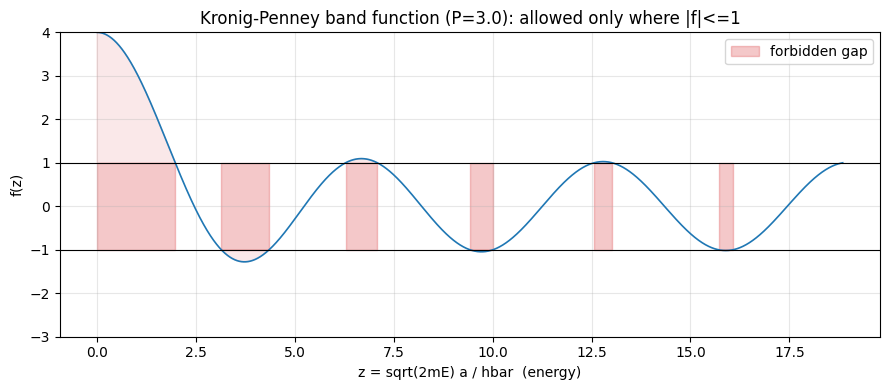

allowed fraction of the energy axis: 0.786


In [2]:
P = 3.0
z = np.linspace(1e-4, 6*np.pi, 4000)
f = kp.kp_rhs(z, P)
plt.figure(figsize=(9,4))
plt.plot(z, f, lw=1.2)
plt.axhline(1, color="k", lw=0.8); plt.axhline(-1, color="k", lw=0.8)
plt.fill_between(z, -1, 1, where=~kp.allowed(z, P), color="C3", alpha=0.25, label="forbidden gap")
plt.fill_between(z, f, np.sign(f), where=np.abs(f)>1, color="C3", alpha=0.1)
plt.ylim(-3, 4); plt.xlabel("z = sqrt(2mE) a / hbar  (energy)"); plt.ylabel("f(z)")
plt.title(f"Kronig-Penney band function (P={P}): allowed only where |f|<=1"); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"allowed fraction of the energy axis: {kp.allowed_fraction(P):.3f}")

## 2. The band structure E(K)

For each allowed energy the Bloch phase is $Ka=\arccos f(z)$. Plotting energy
($\propto z^2$) against $Ka$ gives the **band structure**: curves of allowed states
separated by horizontal **gaps** -- no states at those energies for any $K$.

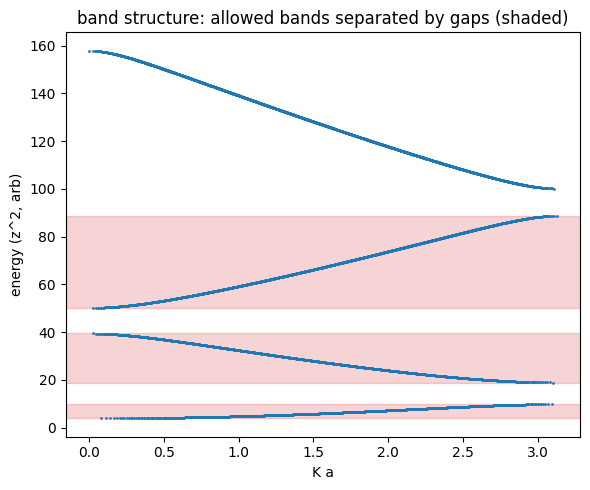

the red strips are band gaps -- forbidden energies


In [3]:
Ka, E = kp.dispersion(P, z_max=4*np.pi, n=8000)
plt.figure(figsize=(6,5))
plt.plot(Ka, E, ".", ms=2)
# shade the energy gaps (where no Ka exists)
edges = kp.band_edges(P, z_max=4*np.pi)
zg = np.linspace(1e-4, 4*np.pi, 8000); forb = ~kp.allowed(zg, P)
for lo, hi in zip(zg[:-1][np.diff(forb.astype(int))==1], zg[1:][np.diff(forb.astype(int))==-1]):
    plt.axhspan(lo**2, hi**2, color="C3", alpha=0.2)
plt.xlabel("K a"); plt.ylabel("energy (z^2, arb)")
plt.title("band structure: allowed bands separated by gaps (shaded)"); plt.tight_layout(); plt.show()
print("the red strips are band gaps -- forbidden energies")

## 3. The knob P: free electron -> bands -> atomic levels

$P$ measures how strongly the lattice grips the electron. At $P=0$ it is **free** (no
gaps, $E\propto K^2$). Crank $P$ up and the allowed bands shrink while the gaps grow --
toward the **tight-binding** limit where bands collapse back to the atom's discrete
levels (Bohr, from the other side).

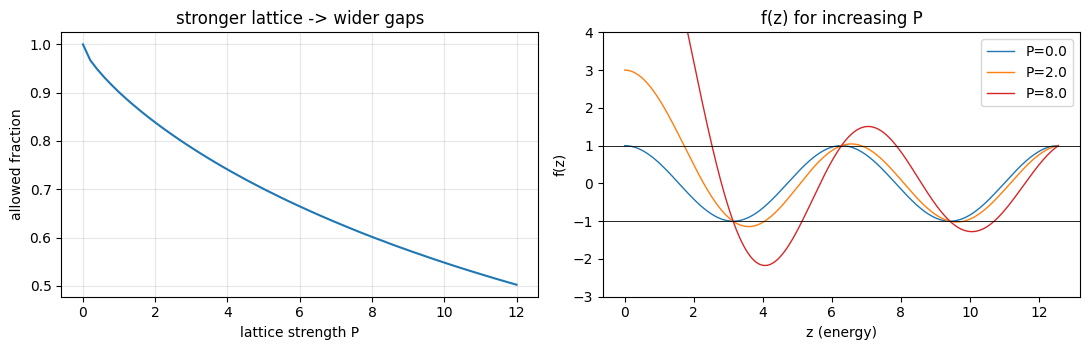

free electron (P=0): allowed everywhere.  strong lattice: narrow bands, wide gaps


In [4]:
Ps = np.linspace(0, 12, 60)
frac = [kp.allowed_fraction(p) for p in Ps]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(Ps, frac); ax[0].set(xlabel="lattice strength P", ylabel="allowed fraction",
          title="stronger lattice -> wider gaps"); ax[0].grid(alpha=0.3)
zz = np.linspace(1e-4, 4*np.pi, 2000)
for p, c in [(0.0,"C0"),(2.0,"C1"),(8.0,"C3")]:
    ax[1].plot(zz, kp.kp_rhs(zz, p), c, lw=1, label=f"P={p}")
ax[1].axhline(1,color="k",lw=0.6); ax[1].axhline(-1,color="k",lw=0.6); ax[1].set_ylim(-3,4)
ax[1].set(xlabel="z (energy)", ylabel="f(z)", title="f(z) for increasing P"); ax[1].legend()
plt.tight_layout(); plt.show()
print("free electron (P=0): allowed everywhere.  strong lattice: narrow bands, wide gaps")

## 4. The payoff: metal, insulator, semiconductor -> the transistor

Electrons fill the bands from the bottom (two per state, Pauli). Where the highest
filled level lands decides everything:
- **partly filled band -> metal** (electrons free to move, conducts).
- **filled band + a gap to the next -> insulator/semiconductor** (must jump the gap).
A **small** gap (~1 eV, silicon) is a *semiconductor*: doping and voltage move
electrons across it on demand -- that switch is the **transistor**, hence every chip.

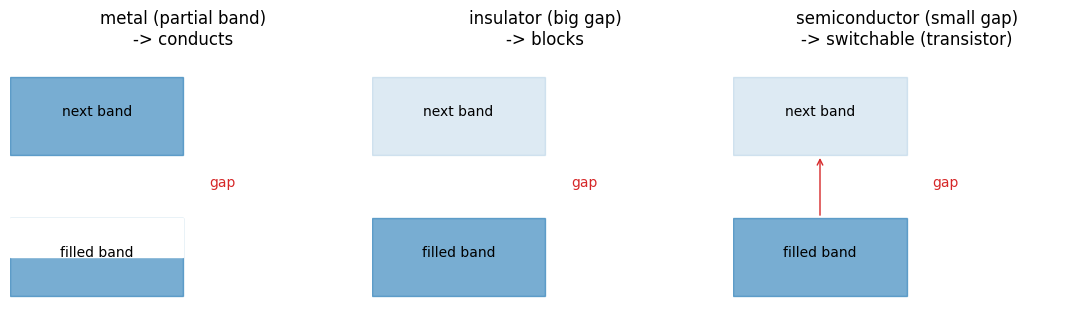

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3.4))
def draw(a, title, fill_top):
    a.add_patch(plt.Rectangle((0,0),1,1, color="C0", alpha=0.6))         # valence band (full)
    a.add_patch(plt.Rectangle((0,1.8),1,1, color="C0", alpha=0.6 if fill_top else 0.15))
    a.text(0.5,0.5,"filled band",ha="center"); a.text(0.5,2.3,"next band",ha="center")
    a.text(1.15,1.4,"gap",color="C3"); a.set(xlim=(0,2), ylim=(-0.3,3.1), title=title); a.axis("off")
draw(ax[0],"metal (partial band)\n-> conducts", True)
ax[0].add_patch(plt.Rectangle((0,0.5),1,0.5, color="white"))             # half-empty
draw(ax[1],"insulator (big gap)\n-> blocks", False)
draw(ax[2],"semiconductor (small gap)\n-> switchable (transistor)", False)
ax[2].annotate("", xy=(0.5,1.8), xytext=(0.5,1.0), arrowprops=dict(arrowstyle="->",color="C3"))
plt.tight_layout(); plt.show()

## What replaces the Bohr model (for a chip)

1. A periodic lattice turns discrete atomic levels into **bands** and **gaps**
   (Kronig-Penney: allowed only where $|f(z)|\le1$).
2. $P=0$ is the free electron ($E\propto K^2$, no gaps); strong $P$ recovers the
   atom's discrete levels -- Bohr at both ends.
3. **Filling** the bands gives metals (partial band), insulators (big gap), and
   **semiconductors** (small gap) -- and the controllable gap is the **transistor**.

So: Bohr -> Schrodinger/orbitals -> **band theory** -> semiconductor devices. This is
the physics a computer engineer actually runs on. Civilian education.